# Backward Cast: Find Alloys for Target Properties

Loads the **synthetic_cast.csv** search pool (from 06_generate_synthetic_cast). You specify desired properties (e.g. UTS, Yield, Conductivity); the notebook finds the top candidate alloys by filtering/sorting the pool. No training—run 01, 02, and 06 first.

In [1]:
import pandas as pd
import numpy as np
import os
import matplotlib.pyplot as plt

INPUT_COLS = ['Al', 'Si', 'Fe', 'Cu', 'Mn', 'Mg', 'Cr', 'Ni', 'Zn', 'Ga', 'V', 'Ti']
POOL_PATH = 'synthetic_cast.csv'
TOP_K = 3

In [2]:
# Load synthetic pool (run 06_generate_synthetic_cast.ipynb first)
if not os.path.exists(POOL_PATH):
    raise FileNotFoundError(f'Not found: {POOL_PATH}. Run 06_generate_synthetic_cast.ipynb first.')
pool = pd.read_csv(POOL_PATH)
prop_cols = [c for c in pool.columns if c not in INPUT_COLS]
print(f'Loaded pool: {pool.shape}. Property columns: {prop_cols}')

Loaded pool: (50000, 21). Property columns: ['Elastic Modulus (GPa)', 'Fatigue Strength (MPa)', 'Shear Modulus (GPa)', 'Tensile Strength: Ultimate (UTS) (MPa)', 'Tensile Strength: Yield (Proof) (MPa)', 'Thermal Conductivity (W/m-K)', 'Electrical Conductivity: Equal Volume (% IACS)', 'Electrical Conductivity: Equal Weight (% IACS)', 'Strength to Weight: Axial (points)']


In [3]:
# Set your target properties (column name -> desired value). Use exact names from pool.
TARGETS = {
    'Tensile Strength: Ultimate (UTS) (MPa)': 300,
    'Tensile Strength: Yield (Proof) (MPa)': 200,
}
# Adjust keys to match prop_cols printed above

In [4]:
# Filter to targets that exist in pool; compute weighted total error and sort
targets_in_pool = {k: v for k, v in TARGETS.items() if k in pool.columns}
if not targets_in_pool:
    raise ValueError('None of TARGETS keys found in pool. Available:', prop_cols)

df = pool.copy()
total_error = np.zeros(len(df))
for col, target_val in targets_in_pool.items():
    scale = max(abs(target_val), 1.0) if target_val != 0 else 1.0
    total_error += np.abs(df[col].values - target_val) / scale
df['Total_Error'] = total_error
winners = df.sort_values('Total_Error').head(TOP_K)

print(f"[{'='*25} BACKWARD CAST: OPTIMAL ALLOYS {'='*25}]")
print(f"  Target properties: {targets_in_pool}\n")
for i, (idx, row) in enumerate(winners.iterrows()):
    print(f"--- CANDIDATE #{i+1} ---")
    for col in targets_in_pool:
        print(f"  {col}: {row[col]:.2f}")
    comp = {el: float(row[el]) for el in INPUT_COLS}
    total = sum(comp.values())
    if total < 100.0:
        comp['Al'] = comp['Al'] + (100.0 - total)
    elif total > 100.0:
        scale = 100.0 / total
        comp = {el: comp[el] * scale for el in INPUT_COLS}
    recipe = [f"{el}={comp[el]:.2f}%" for el in INPUT_COLS if comp[el] > 0.1]
    print("  Recipe: " + ", ".join(recipe))
    print("  Total: 100.00%")
    print()

[========================= BACKWARD CAST: OPTIMAL ALLOYS =========================]
  Target properties: {'Tensile Strength: Ultimate (UTS) (MPa)': 300, 'Tensile Strength: Yield (Proof) (MPa)': 200}

--- CANDIDATE #1 ---
  Tensile Strength: Ultimate (UTS) (MPa): 299.21
  Tensile Strength: Yield (Proof) (MPa): 199.13
  Recipe: Al=93.01%, Si=3.80%, Cu=2.62%, Mg=0.56%
  Total: 100.00%

--- CANDIDATE #2 ---
  Tensile Strength: Ultimate (UTS) (MPa): 297.52
  Tensile Strength: Yield (Proof) (MPa): 199.13
  Recipe: Al=93.05%, Si=3.57%, Cu=2.73%, Mg=0.65%
  Total: 100.00%

--- CANDIDATE #3 ---
  Tensile Strength: Ultimate (UTS) (MPa): 301.51
  Tensile Strength: Yield (Proof) (MPa): 198.12
  Recipe: Al=93.30%, Si=3.70%, Cu=2.74%, Mg=0.26%
  Total: 100.00%



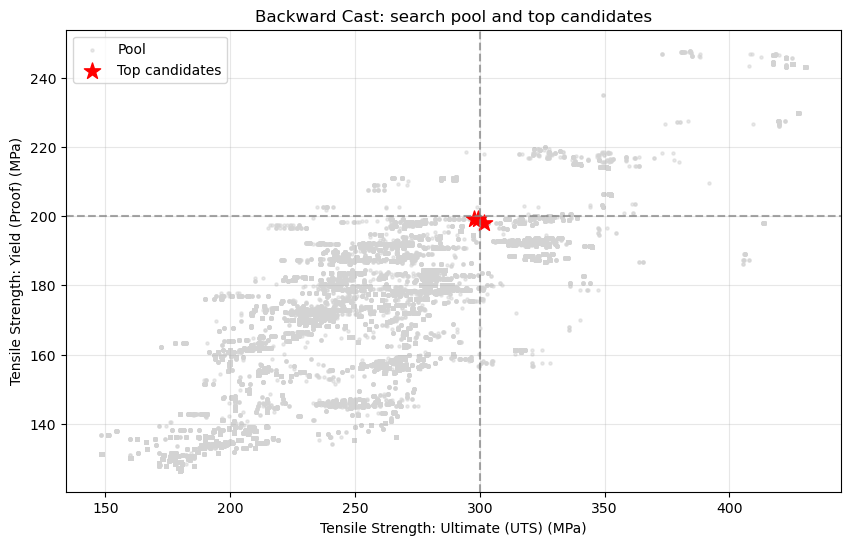

In [5]:
# Optional: 2D plot if exactly two target properties
if len(targets_in_pool) == 2:
    cols = list(targets_in_pool.keys())
    plt.figure(figsize=(10, 6))
    plt.scatter(pool[cols[0]], pool[cols[1]], c='lightgray', s=5, alpha=0.5, label='Pool')
    plt.scatter(winners[cols[0]], winners[cols[1]], c='red', s=150, marker='*', label='Top candidates')
    plt.axvline(TARGETS.get(cols[0]), color='gray', linestyle='--', alpha=0.7)
    plt.axhline(TARGETS.get(cols[1]), color='gray', linestyle='--', alpha=0.7)
    plt.xlabel(cols[0])
    plt.ylabel(cols[1])
    plt.title('Backward Cast: search pool and top candidates')
    plt.legend()
    plt.grid(True, alpha=0.3)
    plt.show()
else:
    print('(Plot skipped: set exactly 2 targets for 2D plot)')